Bohua Liu is responsible for this code

### Convert COCO to YOLO Format (Run only once)

**Explanaition**:
The **TACO** dataset uses the **COCO JSON format**, where all information is stored in a single file.

**Example:**
```json
{
  "images": [
    { "id": 0, "file_name": "batch_1/000006.jpg", "width": 1537, "height": 2049 },
    ...
  ],
  "annotations": [
    { "image_id": 0, "category_id": 5, "bbox": [100, 200, 50, 80] },
    ...
  ],
  "categories": [
    { "id": 5, "name": "plastic_bottle" },
    ...
  ]
}
```

**YOLO** expects a totally different layout:

```
dataset/
 ├── images/
 │   ├── train/
 │   │   └── xxx.jpg
 │   └── val/
 │       └── xxx.jpg
 └── labels/
     ├── train/
     │   └── xxx.txt
     └── val/
         └── xxx.txt
```

Each labels/*.txt file contains one line per object:
```
<class_id> <x_center> <y_center> <width> <height>
```

#### CONFIG

In [ ]:
COCO_JSON   = "TACO/data/annotations.json"   # TACO COCO annotations
IMAGES_ROOT = "TACO/data"                     # TACO images root
YOLO_ROOT   = "taco_yolo"                     # Output YOLO dataset root

# Split ratios
TRAIN_PCT = 0.7
VAL_PCT   = 0.15   # test = 1 - (train + val)

# Random seed for reproducibility
SEED = 42

# Detect on fine-grained TACO categories (True) or merged supercategories (False)
USE_FINE_GRAINED_CLASSES = True

import os, json, shutil, random
from pathlib import Path
from tqdm import tqdm

random.seed(SEED)

# Make output directories
YOLO_ROOT = Path(YOLO_ROOT)
IMG_DIRS = {
    "train": YOLO_ROOT / "images/train",
    "val":   YOLO_ROOT / "images/val",
    "test":  YOLO_ROOT / "images/test",
}
LABEL_DIRS = {
    "train": YOLO_ROOT / "labels/train",
    "val":   YOLO_ROOT / "labels/val",
    "test":  YOLO_ROOT / "labels/test",
}
for d in list(IMG_DIRS.values()) + list(LABEL_DIRS.values()):
    d.mkdir(parents=True, exist_ok=True)

#### PART 1: CONVERT COCO *to* YOLO

In [ ]:

# This builds a standard Ultralytics dataset:
# taco_yolo/
#   images/{train,val,test}/*.jpg|*.png
#   labels/{train,val,test}/*.txt
# Each label file: lines = "<YOLOidx> <xc> <yc> <w> <h>" (all normalized 0..1)

# Load COCO
with open(COCO_JSON, "r") as f:
    coco = json.load(f)

images      = {im["id"]: im for im in coco["images"]}
annotations = coco["annotations"]
categories  = coco["categories"]

# Choose class space: fine-grained (category.name) OR supercategory
"""

| Level             | Example                         | Use Case                                               |
| ----------------- | ------------------------------- | ------------------------------------------------------ |
| **Category**      | `plastic_bottle`, `plastic_bag` | Object detection — detecting and naming specific items |
| **Supercategory** | `Plastic`                       | Material classification — sorting by recyclable type   |


"""
def class_name(cat):
    if USE_FINE_GRAINED_CLASSES: # Controlled in Config
        return cat["name"]
    # supercategory fallback; normalize capitalization
    return (cat.get("supercategory") or "other").strip().lower()

# Build class list and id mapping (COCO category_id -> 0..C-1)
# We want stable ordering; sort by name for determinism.
# Deterministic alphabetical order (e.g., "aluminium_foil", "battery", "bottle") -> Easier to read and debug then sorting by IDs
uniq_names = {}
for c in categories:
    n = class_name(c)
    uniq_names[n] = True
names = sorted(uniq_names.keys())  # YOLO "names:" order

name_to_idx = {n:i for i,n in enumerate(names)}

catid_to_YOLOidx = {}
for c in categories:
    catid_to_YOLOidx[c["id"]] = name_to_idx[class_name(c)]

# Group annotations by image
from collections import defaultdict
anns_by_image = defaultdict(list) # A dict mapping image IDs → their annotations
for a in annotations:
    anns_by_image[a["image_id"]].append(a)

# Train/val/test split on images
image_ids = list(images.keys())
random.shuffle(image_ids)
n_total = len(image_ids)
n_train = int(n_total * TRAIN_PCT)
n_val   = int(n_total * VAL_PCT)
train_ids = set(image_ids[:n_train])
val_ids   = set(image_ids[n_train:n_train + n_val])
test_ids  = set(image_ids[n_train + n_val:])

splits = {"train": train_ids, "val": val_ids, "test": test_ids}

# Helper: COCO bbox -> YOLO normalized row
"""

| concept     | COCO format                                 | YOLO format                                                      |
| ----------- | ------------------------------------------- | ---------------------------------------------------------------- |
| Coordinates | `[x_min, y_min, width, height]` (in pixels) | `[class_id, x_center, y_center, width, height]` (normalized 0-1) |

"""
def coco_bbox_to_yolo_row(ann, width, height):
    # COCO bbox: [x_min, y_min, w, h] in pixels
    x, y, w, h = ann["bbox"]                 # top-left corner (x,y) + width/height
    xc = (x + w/2.0) / width                 # center-x  normalized
    yc = (y + h/2.0) / height                # center-y  normalized
    wn = w / width                           # box-width normalized
    hn = h / height                          # box-height normalized
    YOLOidx = catid_to_YOLOidx[ann["category_id"]]   # map COCO category id → YOLO class index
    # keep numbers inside [0,1] just in case
    xc = min(max(xc, 0.0), 1.0)
    yc = min(max(yc, 0.0), 1.0)
    wn = min(max(wn, 0.0), 1.0)
    hn = min(max(hn, 0.0), 1.0)
    return YOLOidx, xc, yc, wn, hn

# Copy images & write YOLO label files
def convert_one_image(img_id, split): # split is data type: train, val, test
    im = images[img_id]
    im_path = im["file_name"]              # e.g. "batch_1/000006.jpg"
    src = Path(IMAGES_ROOT) / im_path      # Output: /data/taco/images/batch_1/000006.jpg
    if not src.exists():
        return False

    # Split data to train, val and test
    img_saving_dest = IMG_DIRS[split] / f"{img_id}_{src.name}" # Use id to prevent duplication
    shutil.copy2(src, img_saving_dest)

    # Write labels
    label_path = LABEL_DIRS[split] / (img_saving_dest.stem + ".txt") # dst_img.stem is the filename without .jpg, so the label file will have the same base name
    # LABEL_DIRS values are PATH
    W, H = im["width"], im["height"]
    rows = []
    for ann in anns_by_image.get(img_id, []):
        # Skip tiny boxes (optional): some bounding boxes may be nearly invisible or incorrectly labeled.
        if ann["bbox"][2] < 2 or ann["bbox"][3] < 2:
            continue
        YOLOidx, xc, yc, wn, hn = coco_bbox_to_yolo_row(ann, W, H)
        rows.append(f"{YOLOidx} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
    # Even if no objects, create an empty file so YOLO knows it exists
    with open(label_path, "w") as f:
        f.write("\n".join(rows))
    return True


counts = {"train": 0, "val": 0, "test": 0}
for split, idset in splits.items():
    print(f"\nConverting {split.upper()} set ({len(idset)} images)...")
    for img_id in tqdm(idset, desc=f"{split.upper()} progress", unit="img"):
        if convert_one_image(img_id, split):
            counts[split] += 1

print("\nConverted images:", counts)
print("Class count:", len(names))
print("First 15 classes:", names[:15])



Converting TRAIN set (1050 images)...


TRAIN progress: 100%|██████████| 1050/1050 [00:03<00:00, 292.39img/s]



Converting VAL set (225 images)...


VAL progress: 100%|██████████| 225/225 [00:00<00:00, 299.80img/s]



Converting TEST set (225 images)...


TEST progress: 100%|██████████| 225/225 [00:00<00:00, 366.39img/s]



Converted images: {'train': 1050, 'val': 225, 'test': 225}
Class count: 60
First 15 classes: ['Aerosol', 'Aluminium blister pack', 'Aluminium foil', 'Battery', 'Broken glass', 'Carded blister pack', 'Cigarette', 'Clear plastic bottle', 'Corrugated carton', 'Crisp packet', 'Disposable food container', 'Disposable plastic cup', 'Drink can', 'Drink carton', 'Egg carton']


#### Create taco.yaml

**Explanaition:** YOLO needs a small YAML file describing where your dataset lives and what classes it contains, for example:

```
# taco.yaml
path: abs_root/taco_yolo
train: images/train
val: images/val
test: images/test
names:
  0: aluminium_foil
  1: bottle
  2: can
  ...
```

In [7]:
taco_yaml = YOLO_ROOT / "taco.yaml"
abs_root  = Path("/Users/yw/Desktop/final project files") # Modify it if you have different one

with open(taco_yaml, "w") as f:
    f.write(f"""

# Auto-generated YOLO dataset config for TACO
path: {abs_root/YOLO_ROOT.as_posix()}
train: images/train
val: images/val
test: images/test
names:

""")
    for i, n in enumerate(names):
        f.write(f"  {i}: {n}\n")

print("\nWrote:", taco_yaml)
print(taco_yaml.read_text()[:400], " ...")


Wrote: taco_yolo/taco.yaml


# Auto-generated YOLO dataset config for TACO
path: /Users/yw/Desktop/final project files/taco_yolo
train: images/train
val: images/val
test: images/test
names:

  0: Aerosol
  1: Aluminium blister pack
  2: Aluminium foil
  3: Battery
  4: Broken glass
  5: Carded blister pack
  6: Cigarette
  7: Clear plastic bottle
  8: Corrugated carton
  9: Crisp packet
  10: Disposable food container
  11:  ...


**Show examples**

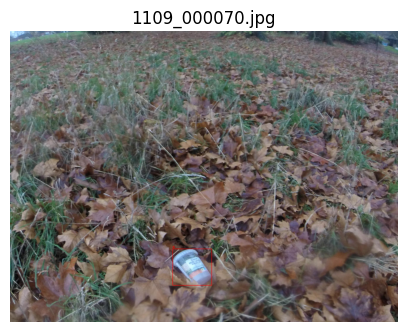

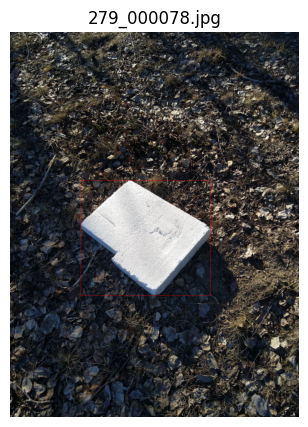

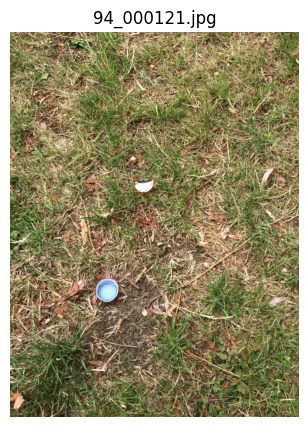

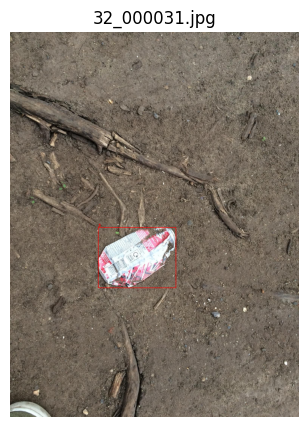

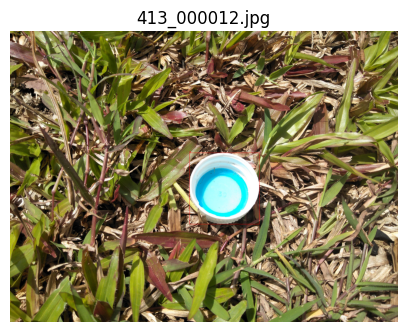

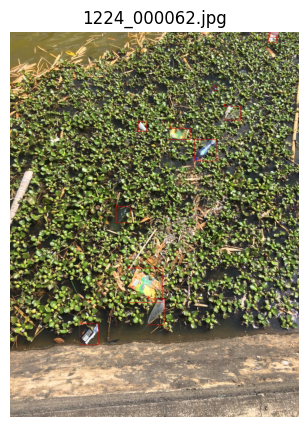

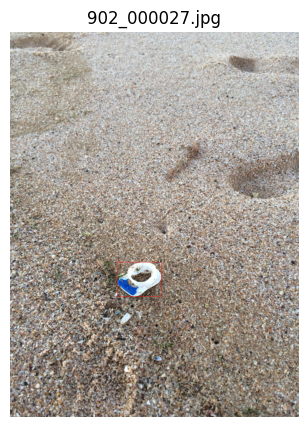

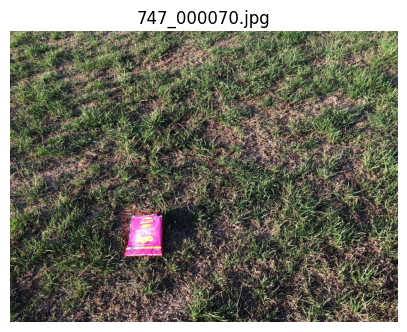

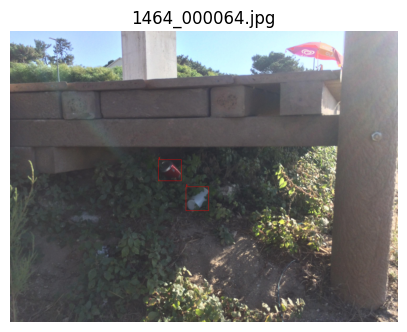

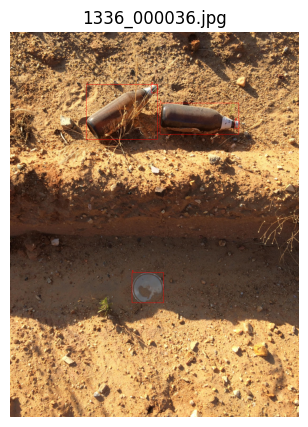

In [8]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt

ROOT = "yolo_4cats"
IMG_DIR = os.path.join(ROOT, "images", "train")
LBL_DIR = os.path.join(ROOT, "labels", "train")

def get_label_path(img_path):
    base = os.path.splitext(os.path.basename(img_path))[0]
    return os.path.join(LBL_DIR, base + ".txt")

def load_yolo_bboxes(label_path, img_w, img_h):
    """
    Load YOLO bounding boxes and convert to pixel coordinates.
    Returns list of (class_id, x1, y1, x2, y2)
    """
    bboxes = []
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls = int(parts[0])
            cx, cy, w, h = map(float, parts[1:])

            # convert to pixel coords
            cx *= img_w
            cy *= img_h
            w *= img_w
            h *= img_h

            x1 = int(cx - w / 2)
            y1 = int(cy - h / 2)
            x2 = int(cx + w / 2)
            y2 = int(cy + h / 2)

            bboxes.append((cls, x1, y1, x2, y2))
    return bboxes

# Load all images
image_paths = sorted(
    glob.glob(os.path.join(IMG_DIR, "*.jpg"))
    + glob.glob(os.path.join(IMG_DIR, "*.png"))
    + glob.glob(os.path.join(IMG_DIR, "*.jpeg"))
)

num_to_show = min(10, len(image_paths))
selected = random.sample(image_paths, num_to_show)

for img_path in selected:
    label_path = get_label_path(img_path)
    if not os.path.exists(label_path):
        print(f"No label found for {img_path}")
        continue

    # Load image
    img_bgr = cv2.imread(img_path)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Load YOLO bounding boxes
    bboxes = load_yolo_bboxes(label_path, w, h)

    # Draw boxes
    for cls, x1, y1, x2, y2 in bboxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, str(cls), (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    # Show
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()
